<a href="https://colab.research.google.com/github/kmeng01/rome/blob/main/notebooks/rome.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" align="left"/></a>&nbsp;or in a local notebook.

# Multi- Rank-One Model Editing (Multi-ROME)
This notebook enables interactive experimentation with Multi-ROME and several other comparable baselines.
The goal is to write new facts (e.g. counterfactuals) into existing pre-trained models with generalization and specificity, where a fact is edited into multiple layers as multiple copies.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
if os.path.basename(os.getcwd()) == "KE4MHQ":
    os.chdir("rome")
!ls


import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from util import nethook
from util.generate import generate_interactive, generate_fast

from experiments.py.demo import demo_model_editing, stop_execution
import json
import time

from util.eval_greedy import eval_editing,eval_old_ans


import numpy as np
import random
import tqdm

def set_seed(seed=42):
    random.seed(seed)  # Python random module
    np.random.seed(seed)  # NumPy
    torch.manual_seed(seed)  # PyTorch CPU
    torch.cuda.manual_seed(seed)  # PyTorch GPU
    torch.cuda.manual_seed_all(seed)  # Multi-GPU
    torch.backends.cudnn.deterministic = True  # Ensure deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disable auto-optimization

set_seed(42)

 baselines	        eval_log-5-15.log	  multi-edit-result
 CITATION.cff	        eval_log-5-20.log	  multi-edit-results
 data		        eval_log-5.log		  notebooks
 dsets		        eval_log-smooth.log	  README.md
 eval_log-10.log        experiments		  results
 eval_log-15.log        globals.yml		  rome
 eval_log-20.log       'hop1-Eval-[10, 15, 20]'   run_experiment.sh
 eval_log-5-10-15.log   hparams			  scripts
 eval_log-5-10-20.log   LICENSE			  util
 eval_log-5-10.log      logs			  wiki-data


Here, you can specify a GPT model (`MODEL_NAME`).

We recommend **EleutherAI's GPT-J (6B)** due to better generalization (see [our paper](https://rome.baulab.info/) for details), but GPT-2 XL (1.5B) consumes less memory.
* `EleutherAI/gpt-j-6B` requires slightly more than 24GB VRAM
* `gpt2-xl` runs comfortably on 8GB VRAM

In [ ]:
IS_COLAB = False
ALL_DEPS = False
try:
    import google.colab, torch, os

    IS_COLAB = True
    os.chdir("/content/rome")
    if not torch.cuda.is_available():
        raise Exception("Change runtime type to include a GPU.")
except ModuleNotFoundError as _:
    pass


# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = 'cpu'
device = torch.device('cuda:1')
print(f"Using device: {device}")

ALG_NAME = "ROME-Multi" # alternatively: "ROME"
MODEL_NAME = "EleutherAI/gpt-j-6B" # alternatively: "gpt2-xl"

json_path_dict = {
    "gpt2-xl":"hparams/ROME/gpt2-xl.json",
    "EleutherAI/gpt-j-6B":"hparams/ROME/EleutherAI_gpt-j-6B.json"
}



Using device: cuda:1


In [4]:

model, tok = (
    AutoModelForCausalLM.from_pretrained(MODEL_NAME, low_cpu_mem_usage=IS_COLAB).to(
        device
    ),
    AutoTokenizer.from_pretrained(MODEL_NAME),
)
tok.pad_token = tok.eos_token
model.config

Some weights of the model checkpoint at EleutherAI/gpt-j-6B were not used when initializing GPTJForCausalLM: ['transformer.h.0.attn.bias', 'transformer.h.0.attn.masked_bias', 'transformer.h.1.attn.bias', 'transformer.h.1.attn.masked_bias', 'transformer.h.10.attn.bias', 'transformer.h.10.attn.masked_bias', 'transformer.h.11.attn.bias', 'transformer.h.11.attn.masked_bias', 'transformer.h.12.attn.bias', 'transformer.h.12.attn.masked_bias', 'transformer.h.13.attn.bias', 'transformer.h.13.attn.masked_bias', 'transformer.h.14.attn.bias', 'transformer.h.14.attn.masked_bias', 'transformer.h.15.attn.bias', 'transformer.h.15.attn.masked_bias', 'transformer.h.16.attn.bias', 'transformer.h.16.attn.masked_bias', 'transformer.h.17.attn.bias', 'transformer.h.17.attn.masked_bias', 'transformer.h.18.attn.bias', 'transformer.h.18.attn.masked_bias', 'transformer.h.19.attn.bias', 'transformer.h.19.attn.masked_bias', 'transformer.h.2.attn.bias', 'transformer.h.2.attn.masked_bias', 'transformer.h.20.attn.bi

GPTJConfig {
  "_attn_implementation_autoset": true,
  "_name_or_path": "EleutherAI/gpt-j-6B",
  "activation_function": "gelu_new",
  "architectures": [
    "GPTJForCausalLM"
  ],
  "attn_pdrop": 0.0,
  "bos_token_id": 50256,
  "embd_pdrop": 0.0,
  "eos_token_id": 50256,
  "gradient_checkpointing": false,
  "initializer_range": 0.02,
  "layer_norm_epsilon": 1e-05,
  "model_type": "gptj",
  "n_embd": 4096,
  "n_head": 16,
  "n_inner": null,
  "n_layer": 28,
  "n_positions": 2048,
  "resid_pdrop": 0.0,
  "rotary": true,
  "rotary_dim": 64,
  "scale_attn_weights": true,
  "summary_activation": null,
  "summary_first_dropout": 0.1,
  "summary_proj_to_labels": true,
  "summary_type": "cls_index",
  "summary_use_proj": true,
  "task_specific_params": {
    "text-generation": {
      "do_sample": true,
      "max_length": 50,
      "temperature": 1.0
    }
  },
  "tie_word_embeddings": false,
  "tokenizer_class": "GPT2Tokenizer",
  "torch_dtype": "float32",
  "transformers_version": "4.49.0",

#  Pipeline for testing multiple insertions on MQuake

In [ ]:



json_path_dict = {
    "gpt2-xl":"hparams/ROME/gpt2-xl.json",
    "EleutherAI/gpt-j-6B":"hparams/ROME/EleutherAI_gpt-j-6B.json"
}



# context used when testing the editted model
context_file = "dsets/rel-prompts.json"
with open(context_file, "r") as f:
    rel_prompts = json.load(f)



def test_multi_rome(
    layers_to_edit, 
    edit_hop, 
    continue_from=0, 
    max_cases=1e9, 
    save_dir=None, 
    kl_factor=0.0625, 
    v_num_grad_steps=20,
    tgt_first_tok_prob=0.2,
    no_edit=False,
):

    with open(json_path_dict[MODEL_NAME], "r") as f:
        data = json.load(f)
    data["layers"] = layers_to_edit
    data["kl_factor"] = kl_factor
    data["v_num_grad_steps"] = v_num_grad_steps
    data["tgt_first_tok_prob"] = tgt_first_tok_prob
    
    with open(json_path_dict[MODEL_NAME], "w") as f:
        json.dump(data, f, indent=2)

    ds_file = "dsets/ds_classification/"+edit_hop+"_edits.json"
    with open(ds_file, "r") as f:
        mhq_ds = json.load(f)

    print("Start time: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()))
    print("layers_to_edit: ", layers_to_edit)
    print("ds_file: ", ds_file)
    correct = 0
    count = 0
    for i in range(len(mhq_ds)):
    # for i in range(100):
        if i < continue_from:
            continue
        if i >= continue_from + max_cases:
            break
        case = mhq_ds[i]
        request = case["requested_rewrite"]
        generation_prompts = []

        print("\n\n"+4*"***********************************************")
        print(f"Request {i+1}, case_id: {case['case_id']}")

        if not no_edit:
            # Restore fresh copy of model
            try:
                with torch.no_grad():
                    for k, v in orig_weights.items():
                        nethook.get_parameter(model, k)[...] = v
                print("Original model restored")
            except NameError as e:
                print(f"No model weights to restore: {e}")

            # Execute rewrite
            model_new, orig_weights = demo_model_editing(
                model, tok, request, generation_prompts, alg_name=ALG_NAME,generate_prompts=False 
                )
            
            eval_fn = eval_editing
        else:
            eval_fn = eval_old_ans

        if save_dir is None:
            # use default save_dir
            save_dir = edit_hop+"-Eval-" + "-".join(map(str, layers_to_edit))

        if eval_fn(model, case, rel_prompts, tok, save_dir=save_dir):
            correct += 1

        count+=1

        print(f"Correct: {correct}/{count}")

    print("End time: ", time.strftime("%Y-%m-%d %H:%M:%S", time.localtime()))

## Test multi-edit on a single case


In [ ]:

# case_index = 66
# hop_to_edit = "hop1" # or "hop2"
# test_multi_rome(
#     layers_to_edit=[[5,8,12,15,18,20]], 
#     edit_hop=hop_to_edit, 
#     continue_from=2, 
#     max_cases=1, 
#     save_dir="smooth-tok1-20",
#     v_num_grad_steps=30,
#     tgt_first_tok_prob=0.8
# )
# test_multi_rome(layers_to_edit=[[5,9,13,17,20]], edit_hop=hop_to_edit, continue_from=0, max_cases=8, save_dir="smooth-20", kl_factor=60)
# test_multi_rome(layers_to_edit=[[5,8,12,15,18,20]], edit_hop=hop_to_edit, continue_from=0, max_cases=8, save_dir="smooth-20-5edits", kl_factor=60)


# case_index = 33
# test_multi_rome(layers_to_edit=[[5,15],[10,20]], edit_hop="both", continue_from=case_index, max_cases=1, save_dir="my_test")

test_multi_rome(layers_to_edit=[[]], edit_hop="hop1", continue_from=0, save_dir="gptj-no-edit-hop1", no_edit=True)
test_multi_rome(layers_to_edit=[[]], edit_hop="hop2", continue_from=0, save_dir="gptj-no-edit-hop2",no_edit=True)


## sweep over different settings

result folder will be saved under KE4MHQ/rome/multi-edit-results

In [6]:


layers_sweep = [
    # [[8]],
    # [[13]],
    [[18]],

    # [[5, 20]]

    # [[5,10,20]]
    # [[10,15,20]],
    

]
hop_sweep = [
    "hop1", 
    "hop2",
    # "both"
]

for layers in layers_sweep:
    for hop in hop_sweep:
        test_multi_rome(layers_to_edit=layers, edit_hop=hop)


Start time:  2025-04-06 22:54:59
layers_to_edit:  [[18]]
ds_file:  dsets/ds_classification/hop1_edits.json


********************************************************************************************************************************************************************************************
Request 1, case_id: 2
No model weights to restore: cannot access local variable 'orig_weights' where it is not associated with a value

###########################################
#                                         #
#  Retrieving ROME-Multi hyperparameters  #
#                                         #
###########################################
Loading from hparams/ROME/EleutherAI_gpt-j-6B.json
ROMEHyperParams(layers=[[18]], fact_token='subject_last', v_num_grad_steps=20, v_lr=0.5, v_loss_layer=27, v_weight_decay=0.5, clamp_norm_factor=4, kl_factor=0.0625, mom2_adjustment=True, context_template_length_params=[[5, 10], [10, 10]], tgt_first_tok_prob=0.2, rewrite_module_tmp='transformer.

We detected that you are passing `past_key_values` as a tuple of tuples. This is deprecated and will be removed in v4.47. Please convert your cache or use an appropriate `Cache` class (https://huggingface.co/docs/transformers/kv_cache#legacy-cache-format)


Cached context templates ['{}', 'Q: . {}', 'Q: . {}', 'The present invention relates. {}', 'The role of the. {}', '\n \n-. {}', 'A new report from. {}', 'Q: . {}', 'Q: . {}', '\n \n=. {}', 'Q: . {}', 'The present invention relates to a method for producing. {}', ' Ask HN: Is there any. {}', " Show HN: I'm looking. {}", 'Q: Is there a way to. {}', ' Show HN: The best way. {}', 'Q: How to make a list. {}', 'Q: How to use a function. {}', 'Q: How do you get the. {}', 'Q: Can I get the current. {}', 'Q: What is a good way. {}']
Computing left vector (u)...
Selected u projection object Aslan
Retrieving inverse covariance statistics for EleutherAI_gpt-j-6B @ transformer.h.18.mlp.fc_out. The result will be cached to avoid repetitive computation.
Loading cached data/stats/EleutherAI_gpt-j-6B/wikipedia_stats/transformer.h.18.mlp.fc_out_float32_mom2_100000.npz


  0%|          | 0/1000 [00:00<?, ?it/s]

Left vector shape: torch.Size([16384])
Computing right vector (v)
Lookup index found: 1 | Sentence: Aslan was created by Charles Stur | Token: lan
Rewrite layer is 18
Tying optimization objective to 27
Recording initial value of v*
loss 5.145 = 5.145 + 0.0 + 0.0 avg prob of [ Charles Sturridge] 0.006765487603843212
loss 3.503 = 3.473 + 0.008 + 0.022 avg prob of [ Charles Sturridge] 0.043591272085905075
loss 1.126 = 1.06 + 0.032 + 0.034 avg prob of [ Charles Sturridge] 0.3873673975467682
loss 0.316 = 0.224 + 0.046 + 0.046 avg prob of [ Charles Sturridge] 0.8124027252197266
loss 0.143 = 0.036 + 0.05 + 0.057 avg prob of [ Charles Sturridge] 0.9653554558753967
loss 0.125 = 0.008 + 0.05 + 0.067 avg prob of [ Charles Sturridge] 0.9917708039283752
loss 0.126 = 0.004 + 0.047 + 0.075 avg prob of [ Charles Sturridge] 0.996394157409668
loss 0.12 = 0.002 + 0.043 + 0.075 avg prob of [ Charles Sturridge] 0.9978116750717163
loss 0.116 = 0.001 + 0.04 + 0.075 avg prob of [ Charles Sturridge] 0.99851709

/home/jeffhe/anaconda3/envs/KE4MHQ_env/lib/python3.11/site-packages/transformers/generation/configuration_utils.py:677: UserWarning: `num_beams` is set to 1. However, `early_stopping` is set to `True` -- this flag is only used in beam-based generation modes. You should set `num_beams>1` or unset `early_stopping`.
  warnings.warn(
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.




++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Evaluating case_id: 2
Evaluation result saved to:  multi-edit-results/hop1-Eval-[18]/j-6B_id_2.json
Correct: 1/1


********************************************************************************************************************************************************************************************
Request 2, case_id: 4
Original model restored

###########################################
#                                         #
#  Retrieving ROME-Multi hyperparameters  #
#                                         #
###########################################
Loading from hparams/ROME/EleutherAI_gpt-j-6B.json
ROMEHyperParams(layers=[[18]], fact_token='subject_last', v_num_grad_steps=20, v_lr=0.5, v_loss_layer=27, v_weight_decay=0.5, clamp_norm_factor=4, kl_factor=0.0625, mom2_adjustment=True, context_template_length_params=[[5, 10], [10, 10]], tgt_first_tok_prob=0.2, re

: 

## Count the accuracy for given folders

In [27]:
import os
import json

# folder_dir = "hop2-Eval-5-10-15-20"
# folder_dir ="both-Eval-[5, 15]-[10, 20]"
# folder_dir = "both-Eval-[5]-[5]"
# folder_dir = "hop2-Eval-[10]"
# folder_dir = "hop2-Eval-[5]"
# folder_dir = "hop1-Eval-[5, 10, 15, 20]"
# folder_dir = "hop2-Eval-5-10-15-20"

folder_dir_sweep = [
    "hop1-Eval-[5]", 
    "hop1-Eval-[10]", 
    "hop1-Eval-[15]", 
    "hop1-Eval-[20]", 
    "hop1-Eval-[5,10,15,20]", 
    # "hop2-Eval-[5]", 
    # "hop2-Eval-[10]", 
    # "hop2-Eval-[15]", 
    # "hop2-Eval-[20]",
    # "hop2-Eval-[5,10,15,20]"
    ]
def check_correctness(folder_dir):
    correct = 0
    total = len(os.listdir(folder_dir))
    # iterate over the json files in the folder
    for filename in os.listdir(folder_dir):
        if filename.endswith(".json"):
            with open(os.path.join(folder_dir, filename), "r") as f:
                results = json.load(f)

                hop_to_check = -3
                # -3: hop1, -2: hop2, -1: 2-hop-reasoning

                # results[-2]["new_answer_alias"] = data["new_answer_alias"]
                # check correctness of the MHQ answer
                results[hop_to_check]["correct"] = results[hop_to_check]["model_responses"]["greedy"].lstrip().\
                                        startswith((results[hop_to_check]["answer"]))
                if results[hop_to_check]["correct"]:
                    correct += 1
                # else:
                #     print(results[0]["case_id"])
    print(f"{folder_dir} Correctness: {correct}/{total}")

for folder_dir in folder_dir_sweep:
    check_correctness("multi-edit-results/"+folder_dir)

multi-edit-results/hop2-Eval-[5,10,15,20] Correctness: 241/359


## Check for overfitted prediction

In [12]:
import os
import json

# folder_dir = "hop2-Eval-5-10-15-20"
# folder_dir ="both-Eval-[5, 15]-[10, 20]"
# folder_dir = "both-Eval-[5]-[5]"
# folder_dir = "hop2-Eval-[10]"
# folder_dir = "hop2-Eval-[5]"
# folder_dir = "hop1-Eval-[5, 10, 15, 20]"
# folder_dir = "hop2-Eval-5-10-15-20"

folder_dir_sweep = [
    "hop1-Eval-[5]", 
    "hop1-Eval-[10]", 
    "hop1-Eval-[15]", 
    "hop1-Eval-[20]", 
    "hop1-Eval-[5,10,15,20]", 
    # "hop2-Eval-[5]", 
    # "hop2-Eval-[10]", 
    # "hop2-Eval-[15]", 
    # "hop2-Eval-[20]",
    # "hop2-Eval-[5,10,15,20]"
    ]
def check_correctness(folder_dir):
    correct = 0
    total = len(os.listdir(folder_dir))
    # iterate over the json files in the folder
    for filename in os.listdir(folder_dir):
        if filename.endswith(".json"):
            with open(os.path.join(folder_dir, filename), "r") as f:
                results = json.load(f)

                hop_to_check = -1
                # -3: hop1, -2: hop2, -1: 2-hop-reasoning

                # results[-2]["new_answer_alias"] = data["new_answer_alias"]
                # check correctness of the MHQ answer
                hop1_correct = results[-3]["model_responses"]["greedy"].lstrip().\
                                        startswith((results[-3]["answer"]))
                hop2_correct = results[-2]["model_responses"]["greedy"].lstrip().\
                                        startswith((results[-2]["answer"]))
                ans_existed = (results[-3]["answer"]).lstrip().\
                                        startswith(tuple(results[hop_to_check]["model_responses"]["top_k_tokens"]) )                 
                overfitted = results[hop_to_check]["model_responses"]["greedy"].lstrip().\
                                        startswith((results[-3]["answer"]))
                if hop2_correct and hop1_correct and overfitted :
                    correct += 1
                # else:
                #     print(results[0]["case_id"])
    print(f"{folder_dir} overfitted: {correct}/{total}")

for folder_dir in folder_dir_sweep:
    check_correctness("multi-edit-results/"+folder_dir)

multi-edit-results/hop1-Eval-[5] overfitted: 79/240
multi-edit-results/hop1-Eval-[10] overfitted: 103/240
multi-edit-results/hop1-Eval-[15] overfitted: 78/240
multi-edit-results/hop1-Eval-[20] overfitted: 21/240
multi-edit-results/hop1-Eval-[5,10,15,20] overfitted: 116/240


## check for ROME failures

In [31]:
import os
import json

def is_single_symbol(s: str) -> bool:
    if s == " ":
        return True
    stripped = s.replace(" ", "")
    return len(stripped) == 1 and not stripped.isalpha() and not stripped.isdigit()

def at_least_three_single_symbols(strings: list[str]) -> bool:
    count = sum(1 for s in strings if is_single_symbol(s))
    return count >= 3

folder_dir_sweep = [
    "hop1-Eval-[5]", 
    "hop1-Eval-[10]", 
    "hop1-Eval-[15]", 
    "hop1-Eval-[20]", 
    # "hop2-Eval-[5]", 
    # "hop2-Eval-[10]", 
    # "hop2-Eval-[15]", 
    # "hop2-Eval-[20]",
    "hop1-Eval-[5,10,15,20]"
    ]
def check_rome_fail(folder_dir):
    correct = 0
    total = len(os.listdir(folder_dir))
    # iterate over the json files in the folder
    for filename in os.listdir(folder_dir):
        if filename.endswith(".json"):
            with open(os.path.join(folder_dir, filename), "r") as f:
                results = json.load(f)

                hop_to_check = -3
                # -3: hop1, -2: hop2, -1:both hops

                # results[-2]["new_answer_alias"] = data["new_answer_alias"]
                # check correctness of the MHQ answer
                if not at_least_three_single_symbols(results[hop_to_check]["model_responses"]["top_k_tokens"].keys()):
                    correct += 1
                # else:
                #     print(results[0]["case_id"])
    print(f"{folder_dir} Correctness: {correct}/{total}")

for folder_dir in folder_dir_sweep:
    check_rome_fail("multi-edit-results/"+folder_dir)

multi-edit-results/hop1-Eval-[5] Correctness: 234/240
multi-edit-results/hop1-Eval-[10] Correctness: 237/240
multi-edit-results/hop1-Eval-[15] Correctness: 239/240
multi-edit-results/hop1-Eval-[20] Correctness: 239/240
multi-edit-results/hop1-Eval-[5,10,15,20] Correctness: 233/240


## draw venn diagram


In [ ]:
! pip install venn

multi-edit-results/hop2-Eval-[5] Correctness: 14/359
multi-edit-results/hop2-Eval-[10] Correctness: 24/359
multi-edit-results/hop2-Eval-[15] Correctness: 32/359
multi-edit-results/hop2-Eval-[20] Correctness: 36/359
multi-edit-results/hop2-Eval-[5,10,15,20] Correctness: 55/359
{'[5]: 14/359': {801, 324, 965, 233, 1098, 1038, 815, 853, 438, 57, 410, 794, 1084, 479}, '[10]: 24/359': {518, 903, 1038, 916, 661, 410, 1051, 801, 815, 438, 184, 57, 58, 1084, 324, 965, 1098, 1100, 1103, 853, 479, 233, 763, 892}, '[15]: 32/359': {7, 8, 1038, 410, 155, 1051, 926, 801, 41, 427, 299, 300, 943, 815, 1075, 179, 181, 58, 1083, 1084, 324, 965, 1098, 76, 213, 853, 858, 479, 995, 233, 763, 892}, '[20]: 36/359': {3, 773, 518, 7, 1038, 915, 661, 410, 1051, 926, 671, 801, 43, 429, 430, 815, 1075, 179, 819, 438, 184, 58, 965, 454, 199, 1098, 76, 853, 858, 1116, 479, 230, 490, 625, 241, 501}, '[5,10,15,20]: 55/359': {386, 773, 518, 903, 8, 1038, 658, 915, 916, 410, 155, 794, 801, 167, 807, 41, 427, 299, 943, 

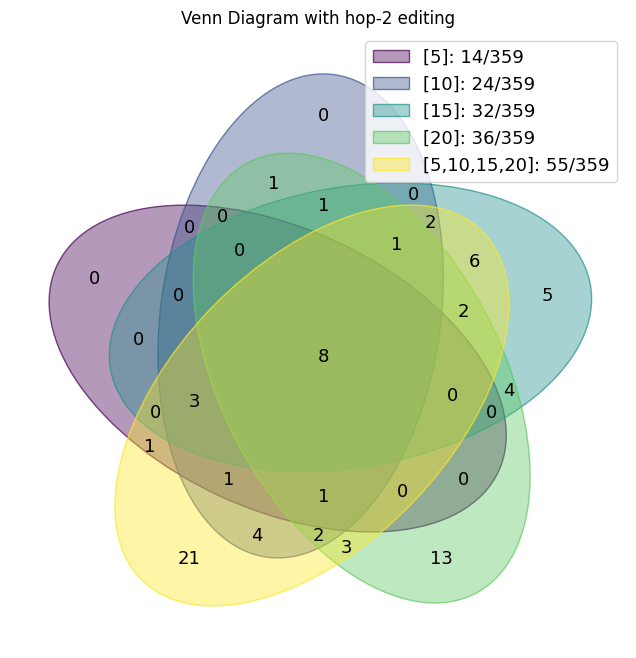

In [65]:
from venn import venn
import matplotlib.pyplot as plt


%matplotlib inline
import os
import json

# folder_dir = "hop2-Eval-5-10-15-20"
# folder_dir ="both-Eval-[5, 15]-[10, 20]"
# folder_dir = "both-Eval-[5]-[5]"
# folder_dir = "hop2-Eval-[10]"
# folder_dir = "hop2-Eval-[5]"
# folder_dir = "hop1-Eval-[5, 10, 15, 20]"
# folder_dir = "hop2-Eval-5-10-15-20"

folder_dir_sweep = [
    # "hop1-Eval-[5]", 
    # "hop1-Eval-[10]", 
    # "hop1-Eval-[15]", 
    # "hop1-Eval-[20]", 
    # "hop1-Eval-[5,10,15,20]",

    "hop2-Eval-[5]", 
    "hop2-Eval-[10]", 
    "hop2-Eval-[15]", 
    "hop2-Eval-[20]",
    "hop2-Eval-[5,10,15,20]"
    ]

lists = {}
for folder in folder_dir_sweep:
    lists[folder] = set()

correctness = {}



def check_correctness(folder_dir):
    correct = 0
    total = len(os.listdir(folder_dir))
    # iterate over the json files in the folder
    for filename in os.listdir(folder_dir):
        if filename.endswith(".json"):
            with open(os.path.join(folder_dir, filename), "r") as f:
                results = json.load(f)

                hop_to_check = -1
                # -3: hop1, -2: hop2, -1:both hops

                # results[-2]["new_answer_alias"] = data["new_answer_alias"]
                # check correctness of the MHQ answer
                results[hop_to_check]["correct"] = results[hop_to_check]["model_responses"]["greedy"].lstrip().\
                                        startswith((results[hop_to_check]["answer"]))
                if results[hop_to_check]["correct"]:
                    correct += 1
                    lists[folder_dir[19:]].add(results[0]["case_id"])
                # else:
                #     print(results[0]["case_id"])
    print(f"{folder_dir} Correctness: {correct}/{total}")
    correctness[folder_dir[19:]] = f"{folder_dir[19:]}: {correct}/{total}"

for folder_dir in folder_dir_sweep:
    check_correctness("multi-edit-results/"+folder_dir)



# # Example lists
# lists = {
#     'List 1': {1, 2, 3, 4, 5},
#     'List 2': {4, 5, 6, 7},
#     'List 3': {5, 6, 7, 8, 9},
# }

# Create proportional Venn diagram
# use correctness dict to label the sets
# Create the Venn diagram with custom labels
# Rename the keys of the sets dictionary using the correctness dictionary
labeled_sets = {correctness[key][10:]: value for key, value in lists.items()}
print(labeled_sets)

# Create the Venn diagram with custom labels
venn(labeled_sets)
plt.title("Venn Diagram with hop-2 editing")
plt.show()

## Evaluation for language metrics

In [ ]:
! CUDA_VISIBLE_DEVICES=3 python3 -m experiments.evaluate --alg_name=ROME-Multi --model_name=EleutherAI/gpt-j-6B --hparams_fname=EleutherAI_gpt-j-6B.json 

! python3 -m experiments.summarize --dir_name=ROME-Multi --runs=run_003


## compute covariance matrix for gpt-j layer>20

In [ ]:
import os
from pathlib import Path

import torch
from datasets import load_dataset
from tqdm.auto import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer

from util.globals import *
from util.nethook import Trace, set_requires_grad
from util.runningstats import CombinedStat, Mean, NormMean, SecondMoment, tally
raw_ds = load_dataset(
            "wikipedia",
            dict(wikitext="wikitext-103-raw-v1", wikipedia="20200501.en", cache_dir='./wiki-data/')["wikipedia"],
            cache_dir='./wiki-data'
        )